In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel('../Dataset/WIID_19Dec2018.xlsx')
df

,id,country,c3,c2,year,gini_reported,q1,q2,q3,q4,...,median_usd,gdp_ppp_pc_usd2011,population,revision,quality,quality_score,source,source_detailed,source_comments,survey
0,1,Afghanistan,AFG,AF,2008,29.00,9.00,13.00,17.00,22.00,...,NaN,1298.0,27294031.0,New 2013,High,12,National statistical authority,European Commission and the Government of Afgh...,National Risk and Vulnerability Assessment,NaN
1,2,Albania,ALB,AL,1996,27.01,9.15,13.70,17.73,23.29,...,1982.0,4812.0,3092228.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
2,3,Albania,ALB,AL,2002,31.74,8.35,12.58,16.49,22.21,...,1902.0,6316.0,3119029.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
3,4,Albania,ALB,AL,2005,30.60,8.40,12.90,17.03,22.50,...,2217.0,7563.0,3079179.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
4,5,Albania,ALB,AL,2008,29.98,8.87,13.07,16.83,22.23,...,2385.0,9018.0,2991651.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11096,11097,Zimbabwe,ZWE,ZW,1995,70.30,1.58,3.64,6.34,11.08,...,NaN,2488.0,11320346.0,NaN,Low,13,World Bank,"Deininger and Squire, World Bank 2004",World Bank. Compilation,"Income, Consumption and Expenditure Survey"
11097,11098,Zimbabwe,ZWE,ZW,2011,42.30,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...
11098,11099,Zimbabwe,ZWE,ZW,2011,37.00,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...
11099,11100,Zimbabwe,ZWE,ZW,2011,39.00,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...


In [3]:
df.columns

Index(['id', 'country', 'c3', 'c2', 'year', 'gini_reported', 'q1', 'q2', 'q3',
       'q4', 'q5', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10',
       'bottom5', 'top5', 'resource', 'resource_detailed', 'scale',
       'scale_detailed', 'sharing_unit', 'reference_unit', 'areacovr',
       'areacovr_detailed', 'popcovr', 'popcovr_detailed', 'region_un',
       'region_un_sub', 'region_wb', 'eu', 'oecd', 'incomegroup', 'mean',
       'median', 'currency', 'reference_period', 'exchangerate', 'mean_usd',
       'median_usd', 'gdp_ppp_pc_usd2011', 'population', 'revision', 'quality',
       'quality_score', 'source', 'source_detailed', 'source_comments',
       'survey'],
      dtype='object')

In [4]:
df.dtypes

id                      int64
country                object
c3                     object
c2                     object
year                    int64
gini_reported         float64
q1                    float64
q2                    float64
q3                    float64
q4                    float64
q5                    float64
d1                    float64
d2                    float64
d3                    float64
d4                    float64
d5                    float64
d6                    float64
d7                    float64
d8                    float64
d9                    float64
d10                   float64
bottom5               float64
top5                  float64
resource               object
resource_detailed      object
scale                  object
scale_detailed         object
sharing_unit           object
reference_unit         object
areacovr               object
areacovr_detailed      object
popcovr                object
popcovr_detailed       object
region_un 

In [5]:
df.isnull().sum()

id                       0
country                  0
c3                       0
c2                       8
year                     0
gini_reported           47
q1                    4004
q2                    4168
q3                    4142
q4                    4136
q5                    4003
d1                    4837
d2                    4843
d3                    4843
d4                    4843
d5                    4823
d6                    4818
d7                    4812
d8                    4815
d9                    4801
d10                   4763
bottom5               9506
top5                  8922
resource                 1
resource_detailed        0
scale                  505
scale_detailed         505
sharing_unit           502
reference_unit          35
areacovr                 0
areacovr_detailed        0
popcovr                  0
popcovr_detailed         0
region_un                0
region_un_sub            0
region_wb                0
eu                       0
o

In [6]:
df.country.unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas, The', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium',
       'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo, Democratic Republic of the',
       'Congo, Republic of the', 'Costa Rica', "Cote d'Ivoire", 'Croatia',
       'Cuba', 'Cyprus', 'Czechia', 'Czechoslovakia', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia, The', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Hai

In [7]:
df['c3'].unique()

array(['AFG', 'ALB', 'DZA', 'AND', 'AGO', 'ARG', 'ARM', 'AUS', 'AUT',
       'AZE', 'BHS', 'BGD', 'BRB', 'BLR', 'BEL', 'BLZ', 'BEN', 'BTN',
       'BOL', 'BIH', 'BWA', 'BRA', 'BGR', 'BFA', 'BDI', 'KHM', 'CMR',
       'CAN', 'CPV', 'CAF', 'TCD', 'CHL', 'CHN', 'COL', 'COM', 'COD',
       'COG', 'CRI', 'CIV', 'HRV', 'CUB', 'CYP', 'CZE', 'CSK', 'DNK',
       'DJI', 'DMA', 'DOM', 'ECU', 'EGY', 'SLV', 'GNQ', 'ERI', 'EST',
       'SWZ', 'ETH', 'FJI', 'FIN', 'FRA', 'GAB', 'GMB', 'GEO', 'DEU',
       'GHA', 'GRC', 'GTM', 'GIN', 'GNB', 'GUY', 'HTI', 'HND', 'HKG',
       'HUN', 'ISL', 'IND', 'IDN', 'IRN', 'IRQ', 'IRL', 'ISR', 'ITA',
       'JAM', 'JPN', 'JOR', 'KAZ', 'KEN', 'KIR', 'KOR', 'KSV', 'KGZ',
       'LAO', 'LVA', 'LBN', 'LSO', 'LBR', 'LTU', 'LUX', 'MKD', 'MDG',
       'MWI', 'MYS', 'MDV', 'MLI', 'MLT', 'MRT', 'MUS', 'MEX', 'FSM',
       'MDA', 'MNG', 'MNE', 'MAR', 'MOZ', 'MMR', 'NAM', 'NRU', 'NPL',
       'NLD', 'NZL', 'NIC', 'NER', 'NGA', 'NOR', 'OMN', 'PAK', 'PLW',
       'PAN', 'PNG',

In [8]:
df['c2'].unique()

array(['AF', 'AL', 'DZ', 'AD', 'AO', 'AR', 'AM', 'AU', 'AT', 'AZ', 'BS',
       'BD', 'BB', 'BY', 'BE', 'BZ', 'BJ', 'BT', 'BO', 'BA', 'BW', 'BR',
       'BG', 'BF', 'BI', 'KH', 'CM', 'CA', 'CV', 'CF', 'TD', 'CL', 'CN',
       'CO', 'KM', 'CD', 'CG', 'CR', 'CI', 'HR', 'CU', 'CY', 'CZ', 'CS',
       'DK', 'DJ', 'DM', 'DO', 'EC', 'EG', 'SV', 'GQ', 'ER', 'EE', 'SZ',
       'ET', 'FJ', 'FI', 'FR', 'GA', 'GM', 'GE', 'DE', 'GH', 'GR', 'GT',
       'GN', 'GW', 'GY', 'HT', 'HN', 'HK', 'HU', 'IS', 'IN', 'ID', 'IR',
       'IQ', 'IE', 'IL', 'IT', 'JM', 'JP', 'JO', 'KZ', 'KE', 'KI', 'KR',
       'KS', 'KG', 'LA', 'LV', 'LB', 'LS', 'LR', 'LT', 'LU', 'MK', 'MG',
       'MW', 'MY', 'MV', 'ML', 'MT', 'MR', 'MU', 'MX', 'FM', 'MD', 'MN',
       'ME', 'MA', 'MZ', 'MM', nan, 'NR', 'NP', 'NL', 'NZ', 'NI', 'NE',
       'NG', 'NO', 'OM', 'PK', 'PW', 'PA', 'PG', 'PY', 'PE', 'PH', 'PL',
       'PT', 'PR', 'QA', 'RE', 'RO', 'RU', 'RW', 'LC', 'WS', 'ST', 'SA',
       'SN', 'RS', 'FY', 'SC', 'SL', 'SG', 'SK', 'SI

In [9]:
df['c2'].fillna('Unknown')

0        AF
1        AL
2        AL
3        AL
4        AL
         ..
11096    ZW
11097    ZW
11098    ZW
11099    ZW
11100    ZW
Name: c2, Length: 11101, dtype: object

In [10]:
df.year.unique()

array([2008, 1996, 2002, 2005, 2012, 1988, 1995, 2001, 2003, 2009, 1953,
       1959, 1961, 1963, 1965, 1969, 1970, 1972, 1974, 1975, 1976, 1977,
       1978, 1979, 1980, 1981, 1982, 1983, 1985, 1986, 1987, 1989, 1990,
       1991, 1992, 1993, 1994, 1997, 1998, 1999, 2000, 2004, 2006, 2007,
       2010, 2011, 2013, 2014, 2015, 2016, 2017, 1942, 1943, 1944, 1945,
       1946, 1947, 1948, 1949, 1950, 1951, 1952, 1954, 1955, 1956, 1957,
       1958, 1960, 1962, 1964, 1966, 1967, 1968, 1971, 1973, 1984, 1939,
       1936, 1890, 1900, 1910, 1920, 1930, 1940, 1914, 1921, 1927, 1938,
       1935, 1867])

In [11]:
df=df.dropna(subset=['gini_reported'])

In [12]:
quintiles=['q1','q2','q3','q4','q5']

for col in quintiles:
    df[col].fillna(df[col].median())

In [13]:
deciles = ['d1','d2','d3','d4','d5','d6','d7','d8','d9','d10']

for dec in deciles:
    df[dec].fillna(df[dec].median())

In [14]:
df.drop(['bottom5','top5'], axis=1)

,id,country,c3,c2,year,gini_reported,q1,q2,q3,q4,...,median_usd,gdp_ppp_pc_usd2011,population,revision,quality,quality_score,source,source_detailed,source_comments,survey
0,1,Afghanistan,AFG,AF,2008,29.00,9.00,13.00,17.00,22.00,...,NaN,1298.0,27294031.0,New 2013,High,12,National statistical authority,European Commission and the Government of Afgh...,National Risk and Vulnerability Assessment,NaN
1,2,Albania,ALB,AL,1996,27.01,9.15,13.70,17.73,23.29,...,1982.0,4812.0,3092228.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
2,3,Albania,ALB,AL,2002,31.74,8.35,12.58,16.49,22.21,...,1902.0,6316.0,3119029.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
3,4,Albania,ALB,AL,2005,30.60,8.40,12.90,17.03,22.50,...,2217.0,7563.0,3079179.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
4,5,Albania,ALB,AL,2008,29.98,8.87,13.07,16.83,22.23,...,2385.0,9018.0,2991651.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11096,11097,Zimbabwe,ZWE,ZW,1995,70.30,1.58,3.64,6.34,11.08,...,NaN,2488.0,11320346.0,NaN,Low,13,World Bank,"Deininger and Squire, World Bank 2004",World Bank. Compilation,"Income, Consumption and Expenditure Survey"
11097,11098,Zimbabwe,ZWE,ZW,2011,42.30,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...
11098,11099,Zimbabwe,ZWE,ZW,2011,37.00,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...
11099,11100,Zimbabwe,ZWE,ZW,2011,39.00,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...


In [15]:
df.sharing_unit.unique()

array(['Household', nan, 'Person', 'Family', 'Tax unit'], dtype=object)

In [16]:
df['sharing_unit'].fillna(df['sharing_unit'].mode()[0])

0        Household
1        Household
2        Household
3        Household
4        Household
           ...    
11096    Household
11097    Household
11098    Household
11099    Household
11100    Household
Name: sharing_unit, Length: 11054, dtype: object

In [17]:
df.scale.unique()

array(['Per capita', 'Equivalized', 'No adjustment', nan], dtype=object)

In [18]:
df.scale_detailed.unique()

array(['Per capita', 'Equivalized', 'No adjustment', nan,
       'Family per capita', 'Family equivalized, OECD', 'OECD-modified',
       'OECD', 'Economic family equivalized, square root',
       'Family equivalized, square root',
       'Census family equivalized, square root', 'Family equivalized',
       'Household equivalized, social assistance', 'Tax unit per capita',
       'National scale', '1988 revised Jensen scale',
       'Family equivalized, social assistance',
       'Family equivalized, national scale',
       'Tax unit equivalized, square root', '1977 McClements scale',
       'Head of household'], dtype=object)

In [19]:
df['scale'].fillna(df['scale'].mode()[0])
df['scale_detailed'].fillna(df['scale_detailed'].mode()[0])

0        Per capita
1        Per capita
2        Per capita
3        Per capita
4        Per capita
            ...    
11096    Per capita
11097    Per capita
11098    Per capita
11099    Per capita
11100    Per capita
Name: scale_detailed, Length: 11054, dtype: object

In [20]:
df.reference_unit.unique()

array(['Person', 'Household', nan, 'Tax unit', 'Family'], dtype=object)

In [21]:
df['reference_unit'].fillna(df['reference_unit'].mode()[0])

0        Person
1        Person
2        Person
3        Person
4        Person
          ...  
11096    Person
11097    Person
11098    Person
11099    Person
11100    Person
Name: reference_unit, Length: 11054, dtype: object

In [22]:
df['mean'].fillna(df['mean'].median())
df['median'].fillna(df['median'].median())

0        12403.00
1         1982.16
2         1901.52
3         2217.48
4         2385.12
           ...   
11096    12403.00
11097      662.40
11098      571.20
11099     1046.40
11100     1230.48
Name: median, Length: 11054, dtype: float64

In [23]:
df.currency.unique()

array(['Afghan afghani', 'US$2011PPP', nan, 'Euro', 'Angolan kwanza',
       'Argentine peso', 'Local currency unit', 'Argentine austral',
       'Armenian ruble', 'Armenian dram', 'Australian dollar',
       'Local currency units, at current prices', 'Austrian schilling',
       'Azerbaijan ruble', 'Bahamian dollar', 'United States dollar',
       'Bangladeshi rupee', 'Bangladeshi taka 1973', 'Bangladeshi taka',
       'Barbadian dollar', 'Belarusian ruble', 'Belarusian ruble (BYB)',
       'Belarusian ruble (BYB1000)', 'Belgian franc',
       'Bhutanese ngultrum', 'Bolivian boliviano', 'Botswana pula',
       'Brazilian cruzeiro', 'United States dollar 1990',
       'Brazilian real', 'Bulgarian old lev (BGL)', 'Bulgarian lev (BGN)',
       'CFA franc', 'Cambodian riel', 'Central African CFA franc',
       'Canadian dollar', 'Canadian dollar  2016', 'Canadian Dollar',
       'Cape Verdean escudo', 'DMPT', 'Chilean peso', 'Chinese yuan 1986',
       'Chinese yuan', 'Chinese yuan 1988',

In [24]:
df['currency'].fillna("Unknown")

0              Afghan afghani
1                  US$2011PPP
2                  US$2011PPP
3                  US$2011PPP
4                  US$2011PPP
                 ...         
11096       Zimbabwean dollar
11097    United States dollar
11098    United States dollar
11099    United States dollar
11100              US$2011PPP
Name: currency, Length: 11054, dtype: object

In [25]:
df.reference_period.unique()

array(['Month', 'Year', nan, 'Week', 'Day'], dtype=object)

In [26]:
df['reference_period'].fillna("Unknown")

0        Month
1         Year
2         Year
3         Year
4         Year
         ...  
11096    Month
11097    Month
11098    Month
11099    Month
11100     Year
Name: reference_period, Length: 11054, dtype: object

In [27]:
df['exchangerate'].fillna(df['exchangerate'].median())

0         50.249615
1        104.498917
2        140.154516
3         99.870254
4         83.894604
            ...    
11096      0.008675
11097      3.620000
11098      3.620000
11099      3.620000
11100      3.620000
Name: exchangerate, Length: 11054, dtype: float64

In [28]:
df.drop(['mean','median'], axis=1)

,id,country,c3,c2,year,gini_reported,q1,q2,q3,q4,...,median_usd,gdp_ppp_pc_usd2011,population,revision,quality,quality_score,source,source_detailed,source_comments,survey
0,1,Afghanistan,AFG,AF,2008,29.00,9.00,13.00,17.00,22.00,...,NaN,1298.0,27294031.0,New 2013,High,12,National statistical authority,European Commission and the Government of Afgh...,National Risk and Vulnerability Assessment,NaN
1,2,Albania,ALB,AL,1996,27.01,9.15,13.70,17.73,23.29,...,1982.0,4812.0,3092228.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
2,3,Albania,ALB,AL,2002,31.74,8.35,12.58,16.49,22.21,...,1902.0,6316.0,3119029.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
3,4,Albania,ALB,AL,2005,30.60,8.40,12.90,17.03,22.50,...,2217.0,7563.0,3079179.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
4,5,Albania,ALB,AL,2008,29.98,8.87,13.07,16.83,22.23,...,2385.0,9018.0,2991651.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11096,11097,Zimbabwe,ZWE,ZW,1995,70.30,1.58,3.64,6.34,11.08,...,NaN,2488.0,11320346.0,NaN,Low,13,World Bank,"Deininger and Squire, World Bank 2004",World Bank. Compilation,"Income, Consumption and Expenditure Survey"
11097,11098,Zimbabwe,ZWE,ZW,2011,42.30,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...
11098,11099,Zimbabwe,ZWE,ZW,2011,37.00,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...
11099,11100,Zimbabwe,ZWE,ZW,2011,39.00,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...


In [29]:
df['gdp_ppp_pc_usd2011'].fillna(df['gdp_ppp_pc_usd2011'].median())

0        1298.0
1        4812.0
2        6316.0
3        7563.0
4        9018.0
          ...  
11096    2488.0
11097    1667.0
11098    1667.0
11099    1667.0
11100    1667.0
Name: gdp_ppp_pc_usd2011, Length: 11054, dtype: float64

In [30]:
df['population'].fillna(df['population'].median())

0        27294031.0
1         3092228.0
2         3119029.0
3         3079179.0
4         2991651.0
            ...    
11096    11320346.0
11097    14386649.0
11098    14386649.0
11099    14386649.0
11100    14386649.0
Name: population, Length: 11054, dtype: float64

In [31]:
df.revision.unique()

array(['New 2013', 'New 2018', nan, 'New 2007', 'New 2008', 'New 2017'],
      dtype=object)

In [32]:
df['revision'].fillna("Unknown")

0        New 2013
1        New 2018
2        New 2018
3        New 2018
4        New 2018
           ...   
11096     Unknown
11097    New 2013
11098    New 2013
11099    New 2013
11100    New 2018
Name: revision, Length: 11054, dtype: object

In [33]:
df.source_comments.unique()

array(['National Risk and Vulnerability Assessment', 'PovcalNet', nan,
       'UNECLAC. Compilation. Based on National Accounts',
       'Argentina National Development Council', 'Cline 1972',
       'Synthetic estimates (UN-ECLA 1970)', 'UN-ECLA 69',
       'Weisskoff 1970', 'UNECLAC. Compilation',
       'World Bank. Compilation', 'FIDE 1998', 'Second half of the year',
       'First half of the year',
       'Transformative Monitoring for Enhanced Equity (TransMonEE)',
       'Statistical Yearbook', 'Tax data',
       'Commonwealth Taxation Assessments', 'AHES',
       'OECD StatExtract. Income definition until 2011',
       'Household Income and Income Distribution Statistics',
       'OECD StatExtract. New income definition since 2012',
       'Social Security Records', 'UN 1981', 'UN 1985',
       'Labour Force and Household Income Report',
       'Asian Development Bank. Compilation', 'Ohja & Batt 1964',
       'Poverty during the Transition website 9/2000, Milanovic',
       'S

In [34]:
df['source_comments'].fillna("No comments")

0        National Risk and Vulnerability Assessment
1                                         PovcalNet
2                                         PovcalNet
3                                         PovcalNet
4                                         PovcalNet
                            ...                    
11096                       World Bank. Compilation
11097               Zimbabwe Poverty Profile Report
11098               Zimbabwe Poverty Profile Report
11099               Zimbabwe Poverty Profile Report
11100                                     PovcalNet
Name: source_comments, Length: 11054, dtype: object

In [35]:
df.resource.unique()


array(['Consumption', 'Income (net/gross)', 'Income (net)', 'Earnings',
       'Income (gross)', nan], dtype=object)

In [36]:
df['resource'].fillna("Unknown")

0        Consumption
1        Consumption
2        Consumption
3        Consumption
4        Consumption
            ...     
11096    Consumption
11097    Consumption
11098    Consumption
11099    Consumption
11100    Consumption
Name: resource, Length: 11054, dtype: object

In [37]:
df.source.unique()

array(['National statistical authority', 'World Bank', 'Research study',
       'United Nations', 'SEDLAC', 'Luxembourg Income Study', 'OECD',
       'Eurostat', 'Other international organizations'], dtype=object)

In [38]:
df.survey.unique()

array([nan, 'l’Enquesta de Pressupostos Familiars (EPF)',
       'The Inquerito Prioritario sobre as Condicoes de Vida aos Domicilios (IPCVD)',
       'Integrated Survey on the Welfare of Population (IBEP) 2008-2009',
       'Encuesta de Presupuestos de Consumo',
       'Encuesta Sobre Presupuestos de Consumo de las Familias Urbanos, por Niveles de Ingreso para 1963',
       'Encuesta de Consumo de Alimentos',
       'Encuesta de Presupuestos Familiares',
       'Encuesta de Empleo y Desempleo: Suplemento de Ingresos',
       'Encuesta Nacional de Hogares', 'Encuesta Permanente de Hogares',
       'March Census', 'Family Budget Survey', 'March Household Survey',
       'Household Budget Survey',
       'Armenian Household Living Standard Survey',
       'Armenia Integrated Living Conditions Survey', 'Tax data',
       'Survey of Consumer Expenditures', 'Household Expenditure Survey',
       'ASCEF', 'Survey of Income and Housing Costs',
       'Australian Income and Housing Survey',
  

In [39]:
df['survey'].fillna("Unknown")

0                                                  Unknown
1                                                  Unknown
2                                                  Unknown
3                                                  Unknown
4                                                  Unknown
                               ...                        
11096           Income, Consumption and Expenditure Survey
11097    Poverty Income Consumption and Expenditure Sur...
11098    Poverty Income Consumption and Expenditure Sur...
11099    Poverty Income Consumption and Expenditure Sur...
11100                                              Unknown
Name: survey, Length: 11054, dtype: object

In [40]:
df.country.value_counts()

country
Canada           368
United States    306
Germany          289
China            258
Finland          245
                ... 
Samoa              1
Reunion            1
Somalia            1
Tuvalu             1
Vanuatu            1
Name: count, Length: 187, dtype: int64

In [41]:
df.c2.value_counts()

c2
CA    368
US    306
DE    289
CN    258
FI    245
     ... 
LC      1
RE      1
SO      1
TV      1
VU      1
Name: count, Length: 185, dtype: int64

In [42]:
df.revision.value_counts()

revision
New 2018    5881
New 2013     343
New 2008     220
New 2007     139
New 2017      17
Name: count, dtype: int64

In [43]:
df.quality.value_counts()

quality
High         5958
Average      3079
Low          1811
Not known     206
Name: count, dtype: int64

In [44]:
df.source.value_counts()

source
Research study                       2506
World Bank                           2355
OECD                                 1297
National statistical authority       1238
United Nations                       1229
Luxembourg Income Study              1073
SEDLAC                                726
Eurostat                              546
Other international organizations      84
Name: count, dtype: int64

In [45]:
df.source_detailed.value_counts()

source_detailed
World Bank 2018                                          1647
OECD 2018                                                1297
LIS 2018                                                 1066
SEDLAC 2018                                               718
ECLAC                                                     599
                                                         ... 
Swiss Federal Statistical Office                            1
van Ginneken 1976                                           1
Dookeran 1981                                               1
Ahiram 1966                                                 1
European Commission and the Government of Afghanistan       1
Name: count, Length: 370, dtype: int64

In [46]:
df.survey.value_counts()

survey
Household Budget Survey                                                                             384
Tax data                                                                                            258
Current Population Survey                                                                           170
Household Income and Expenditure Survey                                                             151
Survey of Labour and Income Dynamics                                                                128
                                                                                                   ... 
Living Conditions Monitoring Survey I                                                                 1
Living Conditions Monitoring Survey II                                                                1
Encuesta de Consumo de Alimentos                                                                      1
Encuesta Sobre Presupuestos de Consumo de las Familias Ur

In [47]:
df.dtypes

id                      int64
country                object
c3                     object
c2                     object
year                    int64
gini_reported         float64
q1                    float64
q2                    float64
q3                    float64
q4                    float64
q5                    float64
d1                    float64
d2                    float64
d3                    float64
d4                    float64
d5                    float64
d6                    float64
d7                    float64
d8                    float64
d9                    float64
d10                   float64
bottom5               float64
top5                  float64
resource               object
resource_detailed      object
scale                  object
scale_detailed         object
sharing_unit           object
reference_unit         object
areacovr               object
areacovr_detailed      object
popcovr                object
popcovr_detailed       object
region_un 

In [48]:
df.describe()

,id,year,gini_reported,q1,q2,q3,q4,q5,d1,d2,...,bottom5,top5,mean,median,exchangerate,mean_usd,median_usd,gdp_ppp_pc_usd2011,population,quality_score
count,11054.000000,11054.000000,11054.000000,7050.000000,6886.000000,6912.000000,6918.000000,7051.000000,6239.000000,6233.000000,...,1586.000000,2170.000000,5.754000e+03,4.510000e+03,1.008800e+04,1654.000000,1650.000000,7645.000000,1.099600e+04,11054.000000
mean,5558.349014,1995.461010,38.648382,6.130498,10.737855,15.160378,21.629725,46.351699,2.313411,3.797048,...,1.064691,18.553507,4.111180e+05,3.023499e+05,2.679137e+02,6126.838573,4903.558788,21673.337475,7.431672e+07,10.984350
std,3204.299426,15.737915,10.444241,2.384527,2.663809,2.502287,1.894730,8.718314,1.100270,1.312695,...,0.396143,6.898680,2.480542e+06,1.860911e+06,1.326169e+03,5807.456965,5057.151557,16684.168649,2.048804e+08,2.317944
min,1.000000,1867.000000,12.100000,0.200000,1.300000,4.200000,10.600000,25.500000,0.000000,0.200000,...,0.100000,9.100000,4.000000e-01,0.000000e+00,8.099705e-14,276.000000,196.000000,495.000000,1.053100e+04,3.000000
25%,2788.250000,1987.000000,30.400000,4.100000,8.600000,13.200000,20.600000,39.220000,1.400000,2.700000,...,0.800000,14.002500,3.547350e+03,3.332000e+03,1.000000e+00,2100.250000,1542.000000,8517.000000,5.164242e+06,10.000000
50%,5558.500000,1999.000000,37.000000,6.130000,11.000000,15.710000,22.060000,44.520000,2.240000,3.810000,...,1.095000,16.140000,1.292520e+04,1.240300e+04,3.620000e+00,3997.000000,2859.000000,16592.000000,1.367103e+07,11.000000
75%,8333.750000,2008.000000,46.800000,8.000000,12.900000,17.220000,22.800000,53.200000,3.190000,4.880000,...,1.360000,21.087500,3.805750e+04,3.045100e+04,2.296035e+01,7472.750000,5909.500000,33233.000000,4.889584e+07,13.000000
max,11101.000000,2017.000000,78.600000,14.600000,17.200000,20.700000,31.800000,81.400000,7.000000,7.600000,...,2.290000,60.000000,4.827100e+07,4.544640e+07,2.594166e+04,26616.000000,23023.000000,122637.000000,1.403500e+09,13.000000


## Global Inequality Distribution 
### Visualization of Distribution of Inequality

<function matplotlib.pyplot.show(close=None, block=None)>

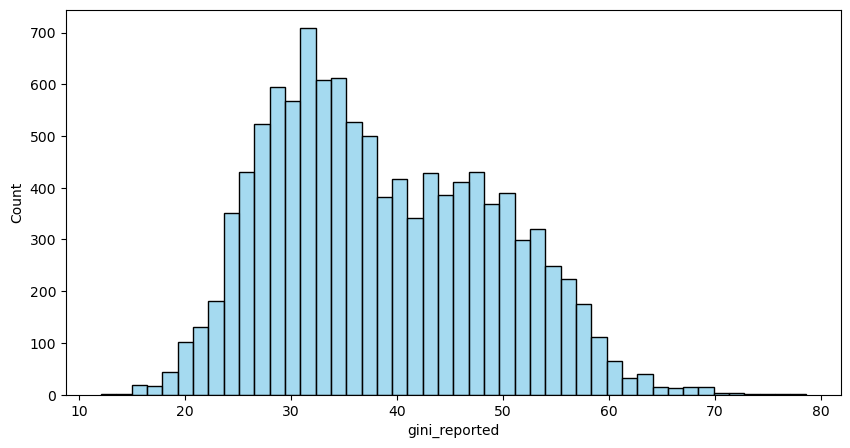

In [49]:
plt.figure(figsize=(10,5))
sb.histplot(df.gini_reported,color='skyblue',edgecolor='black')
plt.show

### How is Income inequality distributed across different countries?

In [50]:
d= df.groupby('country')['gini_reported'].mean().sort_values(ascending=False)

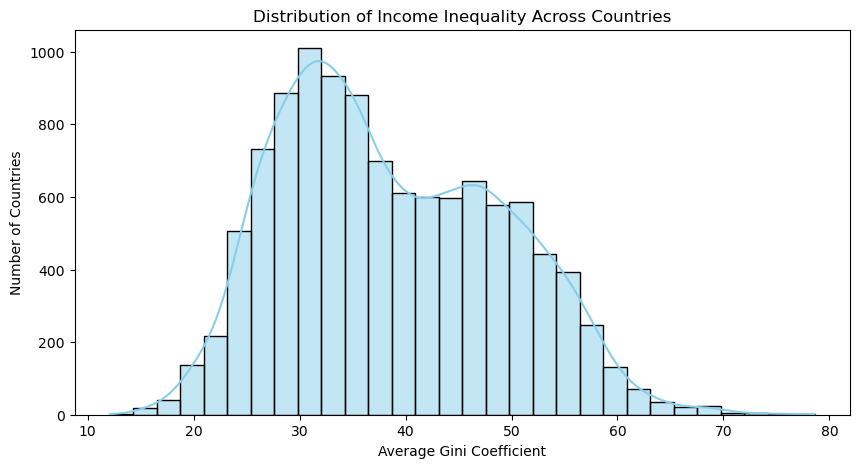

In [51]:
plt.figure(figsize=(10,5))
sb.histplot(df['gini_reported'], bins=30, kde=True,color='skyblue',edgecolor='black')
plt.title("Distribution of Income Inequality Across Countries")
plt.xlabel("Average Gini Coefficient")
plt.ylabel("Number of Countries")
plt.show()

#### The highest concentration of countries lies around 30–35 Gini, indicating that most countries have moderate levels of income inequality.
#### There is another noticeable concentration in the 40–50 Gini range, 
#### showing that a significant number of countries experience high inequality levels.
#### The distribution also has a long right tail extending up to 70–80 Gini, 
#### which indicates that very high inequality exists but is limited to a few countries.

### How is Income inequality distributed across different countries?


In [52]:
country_gini = df.groupby('country')['gini_reported'].mean().reset_index()

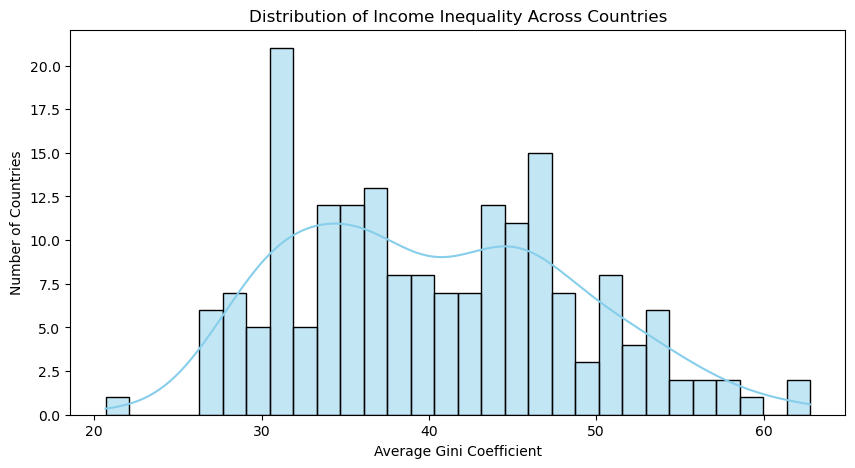

In [53]:
plt.figure(figsize=(10,5))
sb.histplot(country_gini['gini_reported'], bins=30, kde=True,color='skyblue')
plt.title("Distribution of Income Inequality Across Countries")
plt.xlabel("Average Gini Coefficient")
plt.ylabel("Number of Countries")
plt.show()

#### The most countries have moderate income inequality, with Gini values around 30–35.
#### A secondary concentration between 40–50 indicates many countries also have high inequality.
#### The distribution is right-skewed, meaning a few countries have very high inequality (up to 60+),
#### while very low inequality is rare.

##  Regional Inequality Distribution 
###  How does Income inequality vary across different regions?
#### Average Gini coefficient for each region

C:\Users\admin\AppData\Local\Temp\ipykernel_11800\1867688558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=df.gini_reported, y=df.region_un,palette='pastel',edgecolor='black')


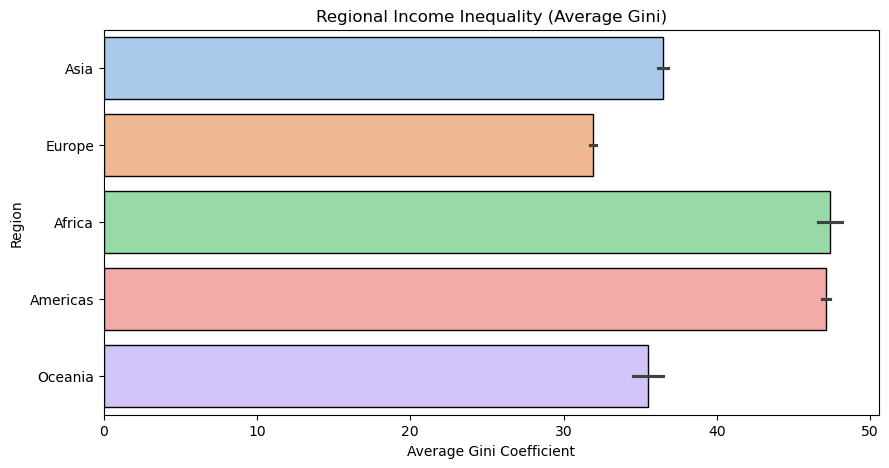

In [54]:
df.groupby('region_un')['gini_reported'].mean().reset_index().sort_values(by='gini_reported', ascending=False)

plt.figure(figsize=(10,5))
sb.barplot(x=df.gini_reported, y=df.region_un,palette='pastel',edgecolor='black')
plt.title("Regional Income Inequality (Average Gini)")
plt.xlabel("Average Gini Coefficient")
plt.ylabel("Region")
plt.show()

#### Africa has high income inequality,with a high average Gini value
#### America has relatively high income inequality.
#### Europe low income inequality, indicating more equal income distribution.


### Which regions have the highest average inequality levels?

In [55]:
a=df.groupby('region_un')['gini_reported'].mean().nlargest()
a

region_un
Africa      47.377500
Americas    47.128023
Asia        36.502831
Oceania     35.497077
Europe      31.910684
Name: gini_reported, dtype: float64

### Which regions shows the lowest inequality levels?

In [56]:
df.groupby('region_un')['gini_reported'].mean().nsmallest()

region_un
Europe      31.910684
Oceania     35.497077
Asia        36.502831
Americas    47.128023
Africa      47.377500
Name: gini_reported, dtype: float64

### Which regions have the highest average inequality levels?
###  which regions have the highest inequality levels.

C:\Users\admin\AppData\Local\Temp\ipykernel_11800\587824202.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=a.index, y=a.values,palette='pastel', edgecolor='black')


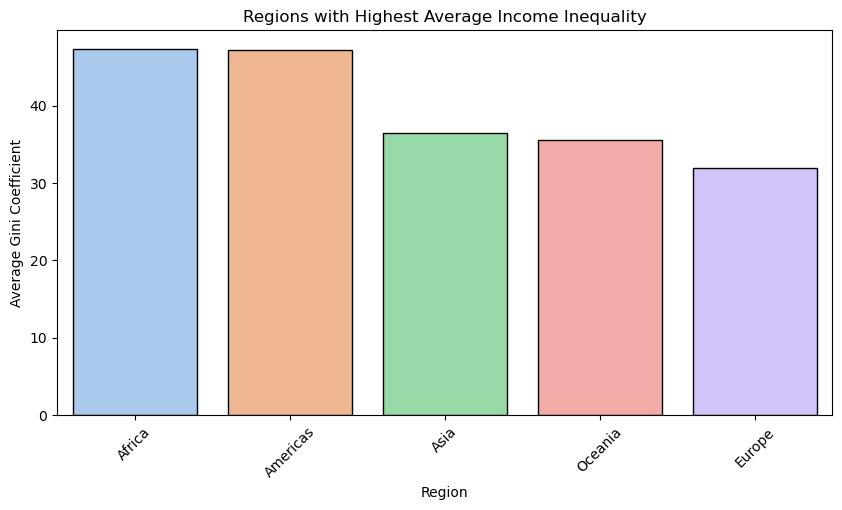

In [57]:
plt.figure(figsize=(10,5))
sb.barplot(x=a.index, y=a.values,palette='pastel', edgecolor='black')
plt.title("Regions with Highest Average Income Inequality")
plt.xlabel("Region")
plt.ylabel("Average Gini Coefficient")
plt.xticks(rotation=45)

plt.show()

#### Africa and the Americas show the highest income inequality.
#### while Europe has the lowest. 
#### Asia and Oceania have moderate inequality levels.

### Are there noticeable regional patterns in Income distribution?
#### Boxplot for Distribution Pattern

C:\Users\admin\AppData\Local\Temp\ipykernel_11800\1714412023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='region_un', y='gini_reported',data=df,palette='pastel')


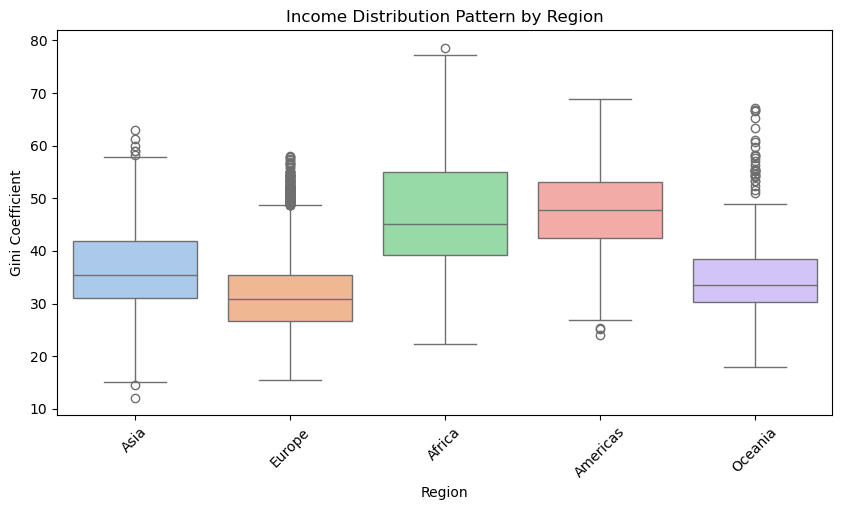

In [58]:
plt.figure(figsize=(10,5))
sb.boxplot(x='region_un', y='gini_reported',data=df,palette='pastel')
plt.title("Income Distribution Pattern by Region")
plt.xlabel("Region")
plt.ylabel("Gini Coefficient")
plt.xticks(rotation=45)

plt.show()

#### Africa shows one of the highest medians (approx. 45–48).
#### Europe has the lowest median Gini coefficient (apprax.30).
#### The Americas have a high median (close to 48).

##  Economic Development vs Inequality 
### Is there any relationship between GDP per capita and Income inequality?
### Check Correlation Between GDP and Inequality

In [59]:
df[['gdp_ppp_pc_usd2011','gini_reported']].corr() 

,gdp_ppp_pc_usd2011,gini_reported
gdp_ppp_pc_usd2011,1.000000,-0.422922
gini_reported,-0.422922,1.000000


### Scatter Plot (GDP vs Inequality)

C:\Users\admin\AppData\Local\Temp\ipykernel_11800\84479814.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.scatterplot(x='gdp_ppp_pc_usd2011', y='gini_reported',data=df,palette='skyblue', edgecolor='black')


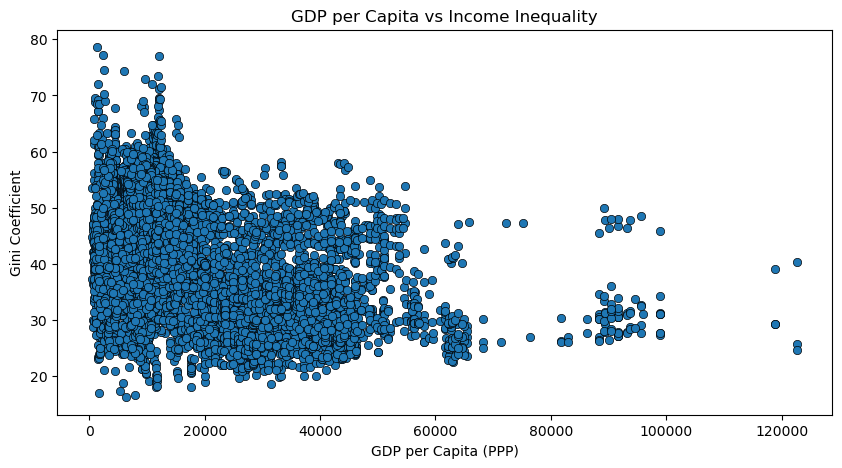

In [60]:
plt.figure(figsize=(10,5))

sb.scatterplot(x='gdp_ppp_pc_usd2011', y='gini_reported',data=df,palette='skyblue', edgecolor='black')

plt.title("GDP per Capita vs Income Inequality")
plt.xlabel("GDP per Capita (PPP)")
plt.ylabel("Gini Coefficient")

plt.show()

### Low ($0 - $20k)	Extremely High Variance, Includes both equal and highly unequal nations.
### Mid ($20k - $60k) Moderate Trend, A visible decline in inequality as wealth increases.
### High (>$60k) Convergence, Most nations cluster in a relatively "equal" zone (Gini 25-45).

### Do countries with higher GDP tend to have lower inequality?

C:\Users\admin\AppData\Local\Temp\ipykernel_11800\1783350057.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x=df.incomegroup, y=df.gini_reported,palette='pastel')


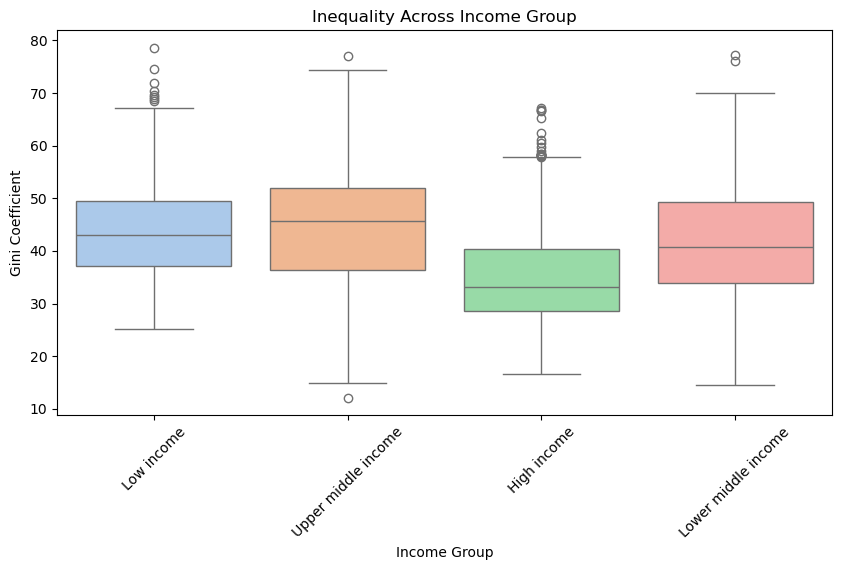

In [61]:
plt.figure(figsize=(10,5))
sb.boxplot(x=df.incomegroup, y=df.gini_reported,palette='pastel')
plt.title("Inequality Across Income Group")
plt.xlabel("Income Group")
plt.ylabel("Gini Coefficient")
plt.xticks(rotation=45)

plt.show()

### The High Income group has the lowest median inequality (Gini ~33) and the most consistent distribution.
### The Upper Middle Income group shows the highest median Gini score (~46), even higher than the low-income group. 
### The Low and Lower Middle Income groups contain the most extreme cases, with outliers reaching Gini scores near 80.

## Income Group Comparsion

In [62]:
df.incomegroup.unique()

array(['Low income', 'Upper middle income', 'High income',
       'Lower middle income'], dtype=object)

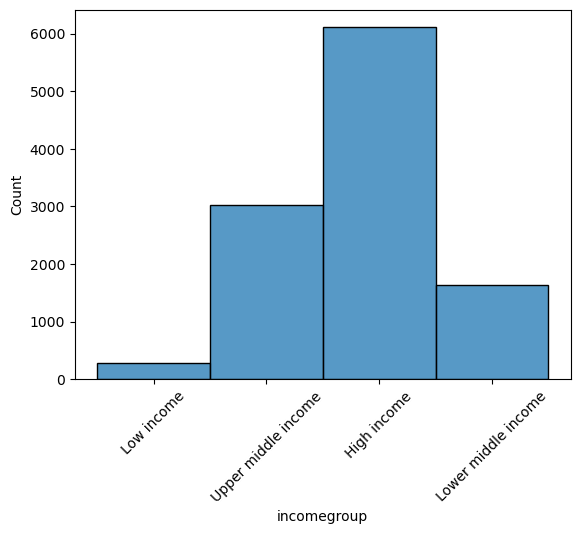

In [63]:
sb.histplot(df.incomegroup)
plt.xticks(rotation=45)
plt.show()

## How does inequality differ between low-income, middle-income, and high-income countries?

C:\Users\admin\AppData\Local\Temp\ipykernel_11800\3726885718.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=c.incomegroup, y=c.gini_reported,palette='pastel', edgecolor='black')


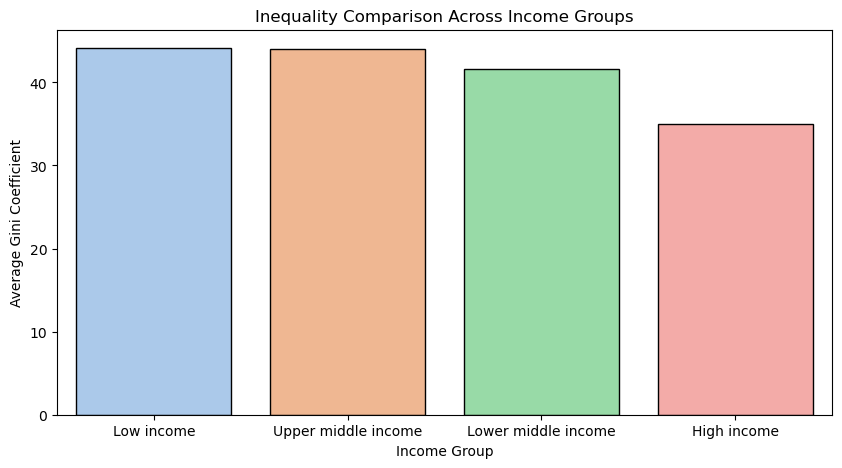

In [64]:
c=df.groupby('incomegroup')['gini_reported'].mean().reset_index().sort_values(by='gini_reported', ascending=False)
plt.figure(figsize=(10,5))
sb.barplot(x=c.incomegroup, y=c.gini_reported,palette='pastel', edgecolor='black')
plt.title("Inequality Comparison Across Income Groups")
plt.xlabel("Income Group")
plt.ylabel("Average Gini Coefficient")
plt.show()

#### The High-income group has the lowest average Gini coefficient, sitting at approximately 35.
#### The Low-income and Upper-middle-income groups have almost identical average Gini scores (roughly 44–45).
#### The Lower-middle-income group shows a slightly lower average (approx. 42) .

##  Which income group shows the greatest inequality variation?

In [65]:
df.groupby('incomegroup')['gini_reported'].std().reset_index().sort_values(by='gini_reported', ascending=False)

,incomegroup,gini_reported
3,Upper middle income,10.796899
2,Lower middle income,10.056125
1,Low income,9.973118
0,High income,8.737194


##  Do wealthier nations consistently maintain lower inequality levels?

In [66]:
cg=df.groupby('country')[['gdp_ppp_pc_usd2011','gini_reported']].sum().sort_values(by='gdp_ppp_pc_usd2011',ascending=False).head(10).reset_index()
cg

,country,gdp_ppp_pc_usd2011,gini_reported
0,Canada,8645035.0,12663.41
1,Luxembourg,8209764.0,3112.51
2,United States,8035145.0,12201.47
3,Germany,7821919.0,9036.53
4,Finland,6790349.0,7474.37
5,Norway,6691558.0,4788.33
6,Denmark,5163186.0,5498.32
7,Netherlands,4575284.0,4719.94
8,United Kingdom,4518750.0,7439.96
9,Italy,3876092.0,5188.54


C:\Users\admin\AppData\Local\Temp\ipykernel_11800\2810411883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=cg.country,y=cg.gini_reported,palette='pastel', edgecolor='black')


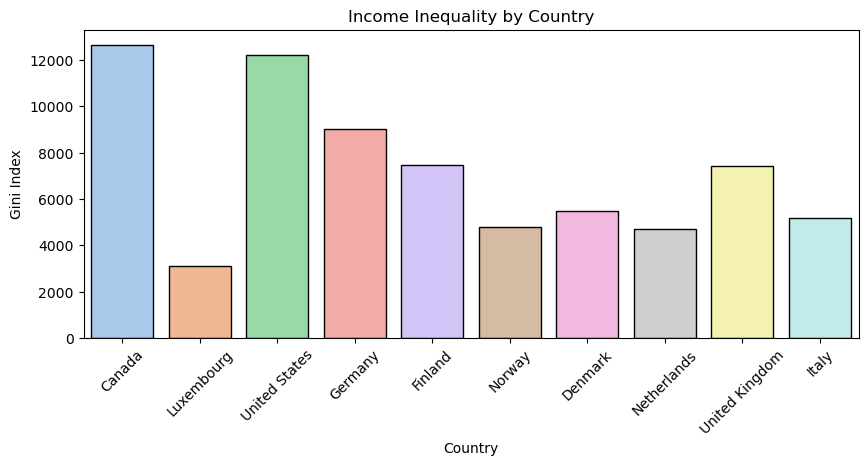

In [67]:
plt.figure(figsize=(10,4))
sb.barplot(x=cg.country,y=cg.gini_reported,palette='pastel', edgecolor='black')
plt.xticks(rotation=45)
plt.title("Income Inequality by Country")  
plt.xlabel("Country")                      
plt.ylabel("Gini Index")  
plt.show()

#### Canada and the United States show the highest Gini Index values both exceeding 12,000.
#### Luxembourg has the lowest income inequality among the countries listed, with a score of approximately 3,100.


## How stable are inequality levels across different income groups?

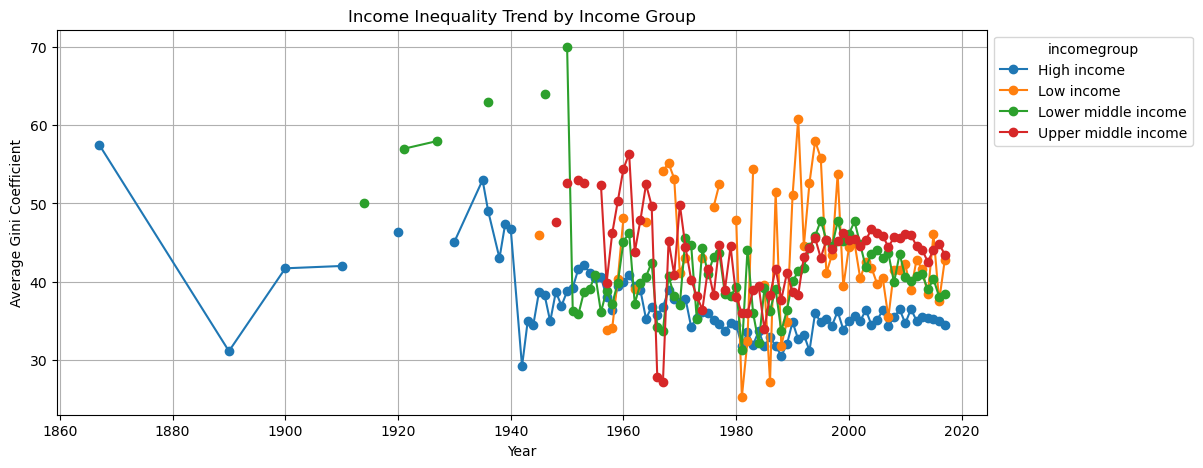

In [68]:
g=df.groupby(['year','incomegroup'])['gini_reported'].mean().unstack()
g.plot(figsize=(12,5),marker='o')
plt.legend(title='incomegroup',bbox_to_anchor=(1.0,1.0))
plt.title("Income Inequality Trend by Income Group")
plt.xlabel("Year")
plt.ylabel("Average Gini Coefficient")
plt.grid(True)
plt.show()


#### Since the 1980s, High-income nations (Blue line) have consistently maintained the lowest and most stable inequality levels (~35 Gini).
#### Low-income countries (Orange line) show the most in inequality during the 1990s.
#### The Lower-middle-income group reached the highest inequality in the (Gini 70) around 1950.
#### Since 2000, High-income nations are significantly more equal (35) than everyone else (45).

In [69]:
f=pd.crosstab(index=df.incomegroup,columns=df.gini_reported)
f

gini_reported,12.10,14.60,15.00,15.50,15.60,15.80,15.90,16.00,16.10,16.23,...,71.50,72.00,73.00,73.40,74.30,74.60,76.00,77.10,77.30,78.60
incomegroup,,,,,,,,,,,,,,,,,,,,,
High income,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Low income,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
Lower middle income,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
Upper middle income,1,0,3,1,1,2,2,4,1,1,...,1,1,1,1,1,0,0,1,0,0


C:\Users\admin\AppData\Local\Temp\ipykernel_11800\4133046699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='incomegroup', y='gini_reported', data=df,palette='pastel')


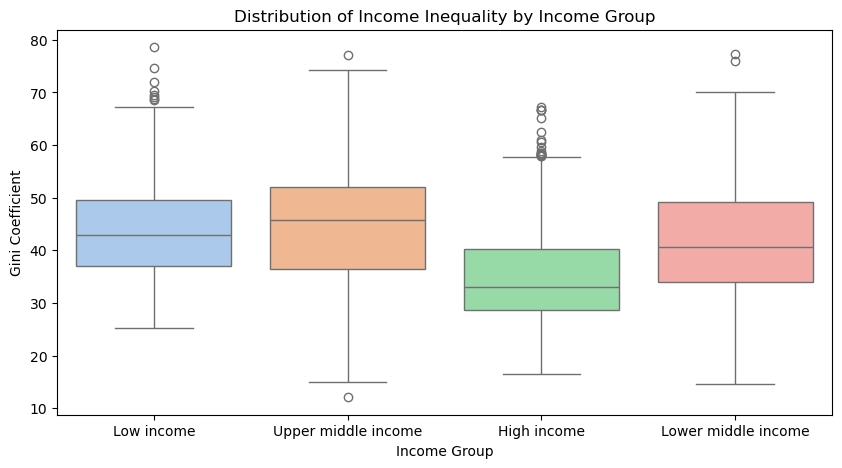

In [70]:
plt.figure(figsize=(10,5))

sb.boxplot(x='incomegroup', y='gini_reported', data=df,palette='pastel')

plt.title("Distribution of Income Inequality by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Gini Coefficient")

plt.show()

#### The High Income group has the lowest median inequality (33)
#### The Upper Middle Income group  shows the highest median Gini score (46), even higher than the low-income group.

## Country-level Inequality Analysis

### Which countries consistently show high inequality levels?

C:\Users\admin\AppData\Local\Temp\ipykernel_11800\880612376.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=top_countries.avg_gini, y=top_countries.country,palette='pastel',edgecolor='black')


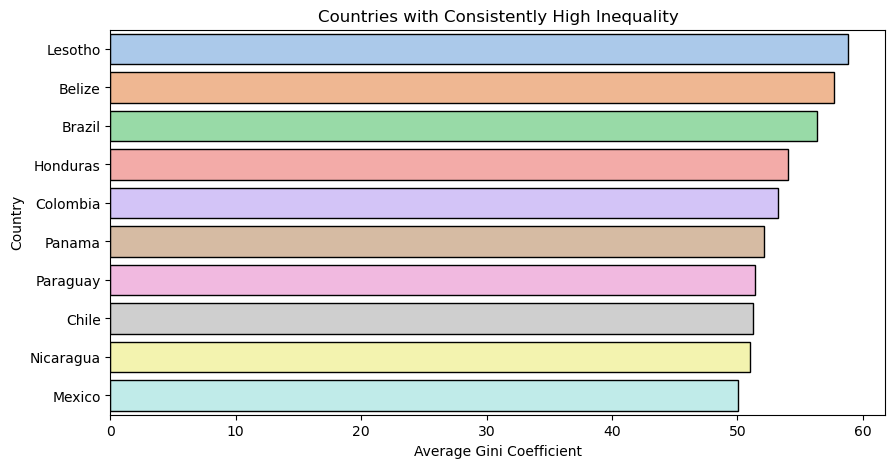

In [71]:
country_gini = df.groupby('country')['gini_reported'].mean().reset_index()
country_std = df.groupby('country')['gini_reported'].std().reset_index()

country_stats = pd.merge(country_gini, country_std, on='country')
country_stats.columns = ['country', 'avg_gini', 'std_gini']

high_inequality = country_stats[(country_stats['avg_gini'] > 45) & (country_stats['std_gini'] < 5)]
high_inequality = high_inequality.sort_values(by='avg_gini', ascending=False)

top_countries = high_inequality.head(10)
plt.figure(figsize=(10,5))
sb.barplot(x=top_countries.avg_gini, y=top_countries.country,palette='pastel',edgecolor='black')
plt.title("Countries with Consistently High Inequality")
plt.xlabel("Average Gini Coefficient")
plt.ylabel("Country")
plt.show()

####  Lesotho has the highest average inequality, with a Gini score nearing 60.
####  Every country on this list has an average Gini score above 50.

### Are there countries where inequality fluctuates significantly over time?


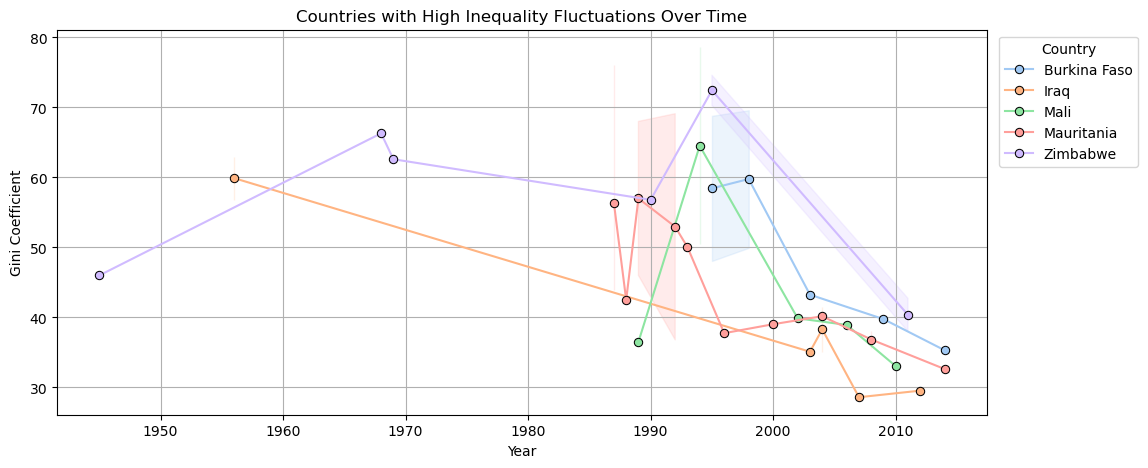

In [72]:
country_fluctuation = df.groupby('country')['gini_reported'].std().reset_index().sort_values(by='gini_reported', ascending=False)

top_fluctuating = country_fluctuation.head(5)['country']

fluct_data = df[df['country'].isin(top_fluctuating)]

plt.figure(figsize=(12,5))
sb.lineplot(x=fluct_data.year, y=fluct_data.gini_reported, hue=fluct_data.country,marker='o',markeredgecolor='black',palette='pastel')
plt.title("Countries with High Inequality Fluctuations Over Time")
plt.xlabel("Year")
plt.ylabel("Gini Coefficient")
plt.legend(title='Country',bbox_to_anchor=(1.17,1.0))
plt.grid(True)
plt.show()

#### Zimbabwe (purple line) reached the highest Gini coefficient in the entire chart, peaking at over 70 in the mid-1990s.
#### Most of these countries (especially Mali, Burkina Faso, and Zimbabwe) experienced their most  in inequality between 1990 and 2000.
#### Since the year 2000, nearly all countries shown (Iraq, Mali, Burkina Faso) have seen a downward trend .

### Which countries demonstrate more equal income distribution?


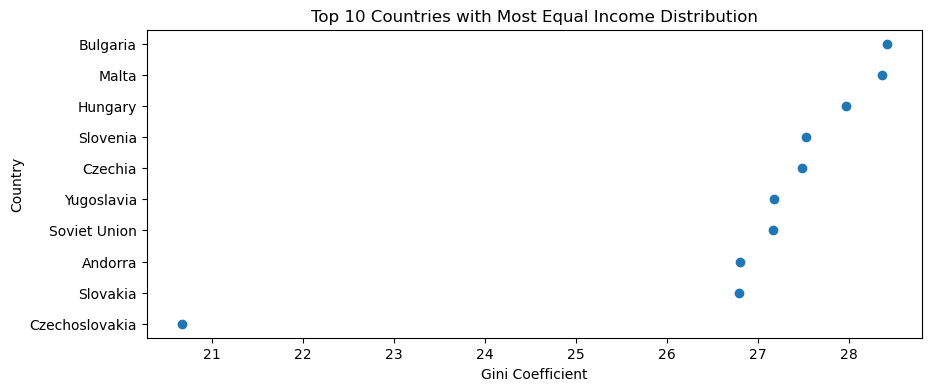

In [73]:
equal_countries = country_gini.sort_values(by='gini_reported').head(10)

plt.figure(figsize=(10,4))
plt.scatter(equal_countries['gini_reported'], equal_countries['country'])
plt.title("Top 10 Countries with Most Equal Income Distribution")
plt.xlabel("Gini Coefficient")
plt.ylabel("Country")
plt.show()

#### Czechoslovakia is the most equal entity in this list, with an exceptionally low Gini score of 20.6.
#### Most of the other top countries (like Slovakia, Soviet Union, and Yugoslavia) are tightly clustered between 26 and 28.5.

### Which Countries show the highest and lowest inequality levels?

C:\Users\admin\AppData\Local\Temp\ipykernel_11800\115626528.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=top10.country, y=top10.gini_reported,palette='pastel', edgecolor='black')
C:\Users\admin\AppData\Local\Temp\ipykernel_11800\115626528.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=bottom10.country, y=bottom10.gini_reported,palette='pastel', edgecolor='black')


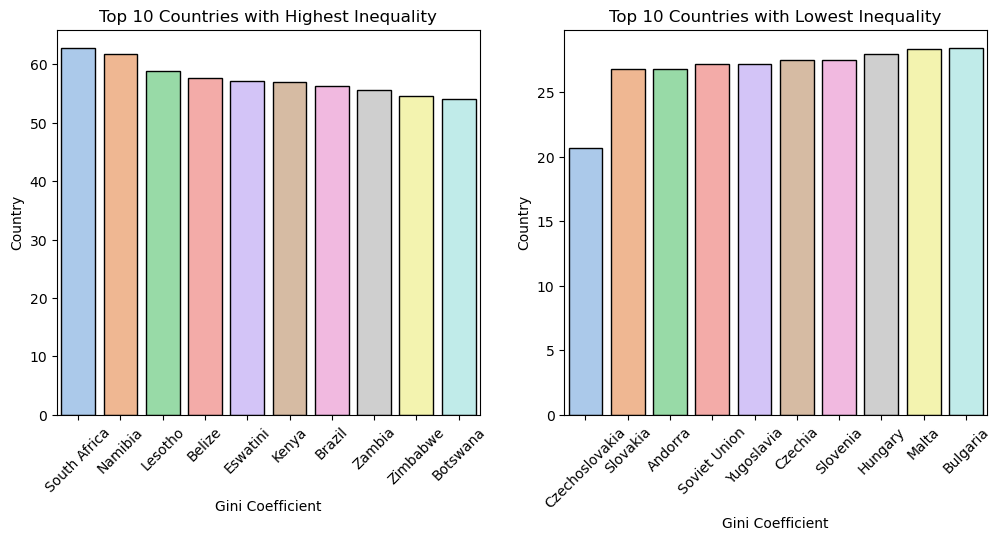

In [74]:
top10 = country_gini.sort_values(by='gini_reported', ascending=False).head(10)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sb.barplot(x=top10.country, y=top10.gini_reported,palette='pastel', edgecolor='black')
plt.title("Top 10 Countries with Highest Inequality")
plt.xlabel("Gini Coefficient")
plt.ylabel("Country")
plt.xticks(rotation=45)

bottom10 = country_gini.sort_values(by='gini_reported').head(10)

plt.subplot(1,2,2)
sb.barplot(x=bottom10.country, y=bottom10.gini_reported,palette='pastel', edgecolor='black')
plt.title("Top 10 Countries with Lowest Inequality")
plt.xlabel("Gini Coefficient")
plt.ylabel("Country")
plt.xticks(rotation=45)

plt.show()

#### Highest Inequality: South Africa has the highest Gini score (above 60).
#### Lowest Inequality: Czechoslovakia is the most equal (~21).

### Which income group shows the greatest inequality variation?


In [75]:
variation = df.groupby('incomegroup')['gini_reported'].std().reset_index().sort_values(by='gini_reported', ascending=False)

highest_variation = variation.iloc[0]

print("Income group with highest inequality variation:\n")
print(highest_variation)

Income group with highest inequality variation:

incomegroup      Upper middle income
gini_reported              10.796899
Name: 3, dtype: object


## Population & Inequality Trend Analysis
### How has income inequality changed over time globally?

C:\Users\admin\AppData\Local\Temp\ipykernel_11800\4284868458.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.lineplot(x=df.year,y=df.gini_reported,marker='o',markeredgecolor='black',palette='pastel')


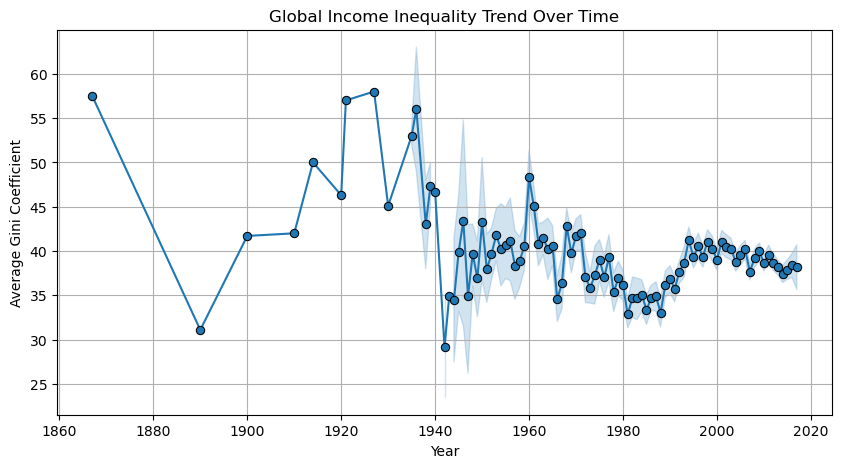

In [76]:
plt.figure(figsize=(10,5))
sb.lineplot(x=df.year,y=df.gini_reported,marker='o',markeredgecolor='black',palette='pastel')
plt.title("Global Income Inequality Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Gini Coefficient")
plt.grid(True)
plt.show()

####  In the 1860s, global inequality started at a very high level (approx. 57).
#### There is a vertical drop around the 1940s, with the Gini index falling to its lowest recorded point (approx. 29).
#### Since the year 2000, the "Average Gini Coefficient" has stabilized.


### Are there periods where inequality increased or decreased significantly?

### Is there any relationship between a country's population size and inequality level?

In [77]:
df[['population','gini_reported']].corr()

,population,gini_reported
population,1.000000,-0.064607
gini_reported,-0.064607,1.000000


C:\Users\admin\AppData\Local\Temp\ipykernel_11800\2738763573.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.scatterplot(x='population',y='gini_reported',data=df,palette='skyblue', edgecolor='black')


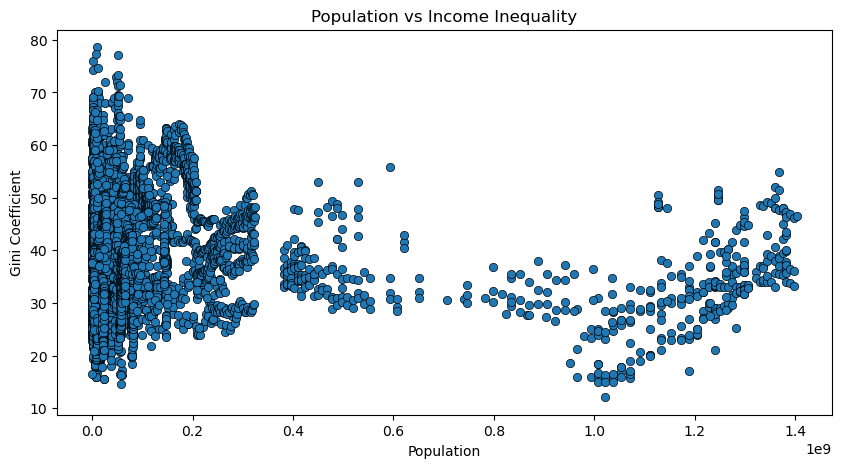

In [78]:
plt.figure(figsize=(10,5))
sb.scatterplot(x='population',y='gini_reported',data=df,palette='skyblue', edgecolor='black')
plt.title("Population vs Income Inequality")
plt.xlabel("Population")
plt.ylabel("Gini Coefficient")
plt.show()

#### The highest inequality levels (Gini scores of 70–80) .
#### In a mid-range between 20 and 55.

### Do highly populated countries tend to have higher inequality?

#### Highly populated countries do not necessarily have higher inequality.  There is no strong relationship between population size and income inequality, as it depends more on economic policies and development.
